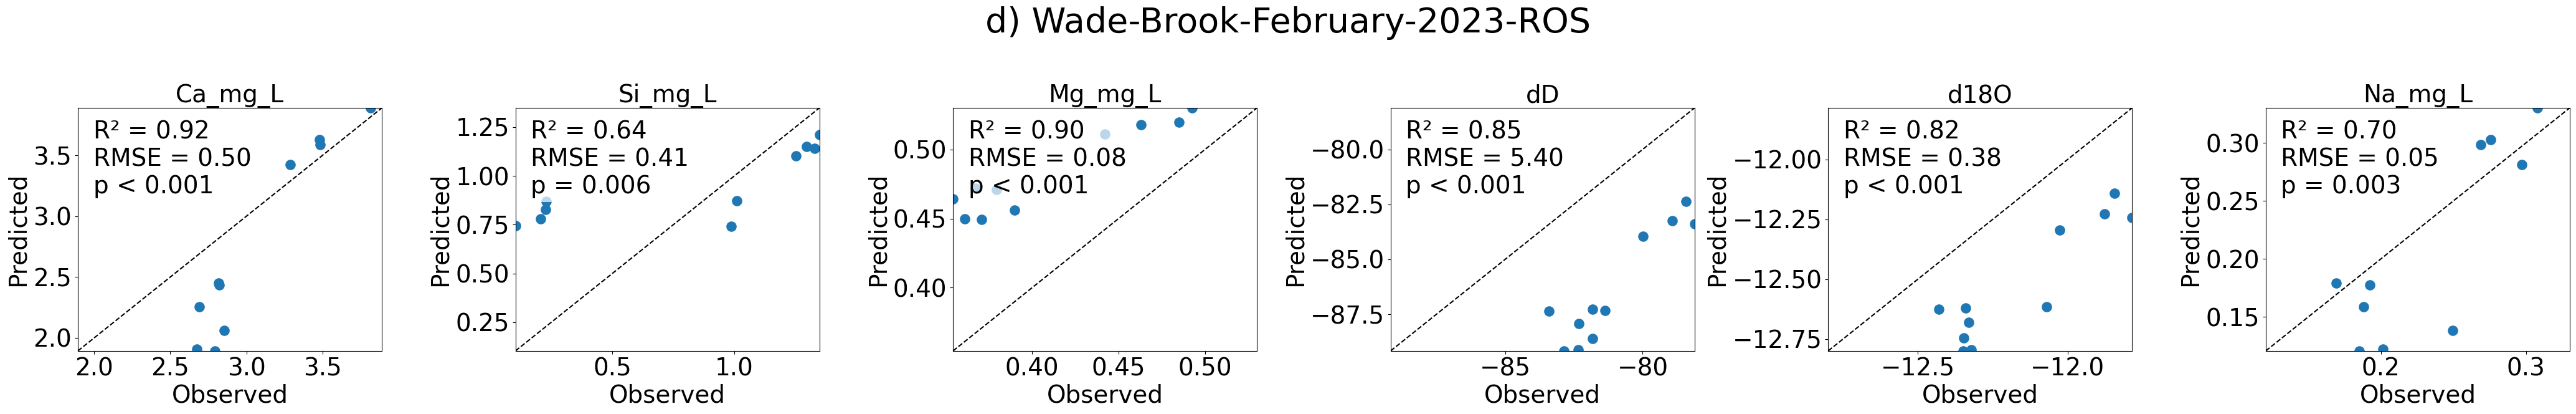

In [19]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data/GrabSample_data"

output_dir = repo_dir / "Output/EMMA-uncertainty/Tracer_regressions/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "RI23-IC-ICP-isotope-toc-joined.csv")

####################
# Wade RI23 events #
####################

# Event A
# Wade February ROS event
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5000 Soil water lysimeter dry 02/15/23
    # RI23-5005 Snowmelt lysimeter 2/15
    # RI23-1034 Pre-event baseflow, labeled as GW in Wade index

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_febros_fractions_df, wade_febros_scaler, wade_febros_pca, wade_febros_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-02-14 00:00:00",
    end_date="2023-02-20 00:00:00",
    endmember_ids=[
                   "RI23-5018", "RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   #"RI23-1034", # Pre-event baseflow, labeled as GW in Wade index
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples        
                   "RI23-5000", # SWL D February 15 2023
                   "RI23-5005", # Snowmelt lysimeter 2/15
                  ], 
)

wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L']

# Call the prediction function
wade_febros_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_febros_fractions_df,
    endmembers_df=wade_febros_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "d) Wade-Brook-February-2023-ROS", 
    predicted_df = wade_febros_predicted, 
    stream_df = df, 
    tracer_cols = wade_tracers,
    output_dir=output_dir)

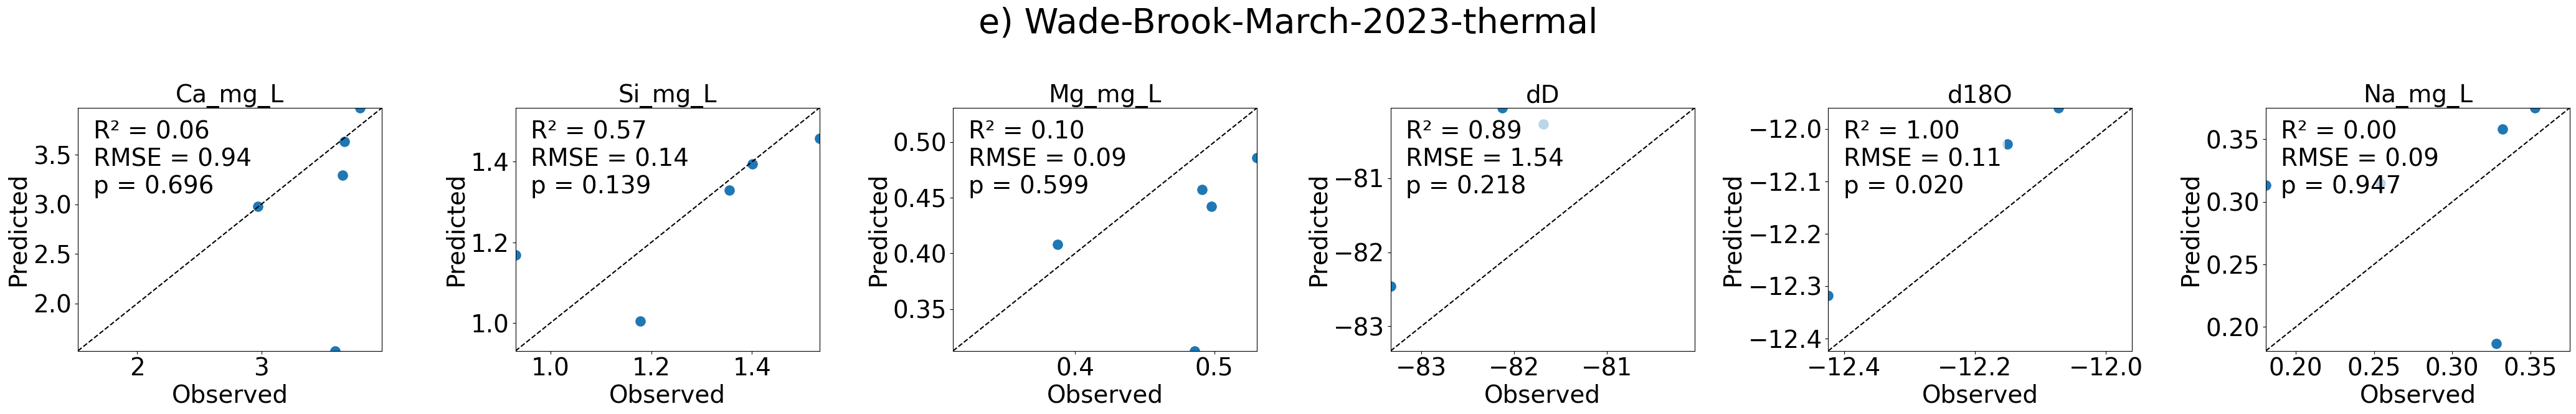

In [20]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data/GrabSample_data"

output_dir = repo_dir / "Output/EMMA-uncertainty/Tracer_regressions/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "RI23-IC-ICP-isotope-toc-joined.csv")

####################
# Wade RI23 events #
####################

# Event B
# Wade March 2023 thermal event
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5000 Soil water lysimeter dry 02/15/23 (removed)
    # RI23-5005 Snowmelt lysimeter 2/15 (removed)
    # RI23-5009 Soil water lysimeter dry 3/16 (removed)
    # RI23-1063 Snowmelt lysimeter 3/28
    # RI23-1034 Baseflow 3/22 (labeled as GW)
    # RI23-5011 Soil water lysimeter wet 4/12

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_martherm_fractions_df, wade_martherm_scaler, wade_martherm_pca, wade_martherm_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-03-21 00:00:00",
    end_date="2023-03-26 00:00:00",
    endmember_ids=[
                   "RI23-5018", "RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   "RI23-1034", # Pre-event baseflow, labeled as GW in Wade index
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples 
                   "RI23-5005", # Snowmelt lysimeter 02/15/2023
                   "RI23-1063", # Snowmelt lysimeter 3/28
                   #"RI23-1098", # Snowmelt lysimeter 04/11/2023
                   #"RI23-5009", # Soil water lysimeter sample
                   "RI23-5011", # Soil water lysimeter wet 4/12
                   ])

wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L']

# Call the prediction function
wade_martherm_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_martherm_fractions_df,
    endmembers_df=wade_martherm_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "e) Wade-Brook-March-2023-thermal", 
    predicted_df = wade_martherm_predicted, 
    stream_df = df, 
    tracer_cols = wade_tracers,
    output_dir=output_dir)

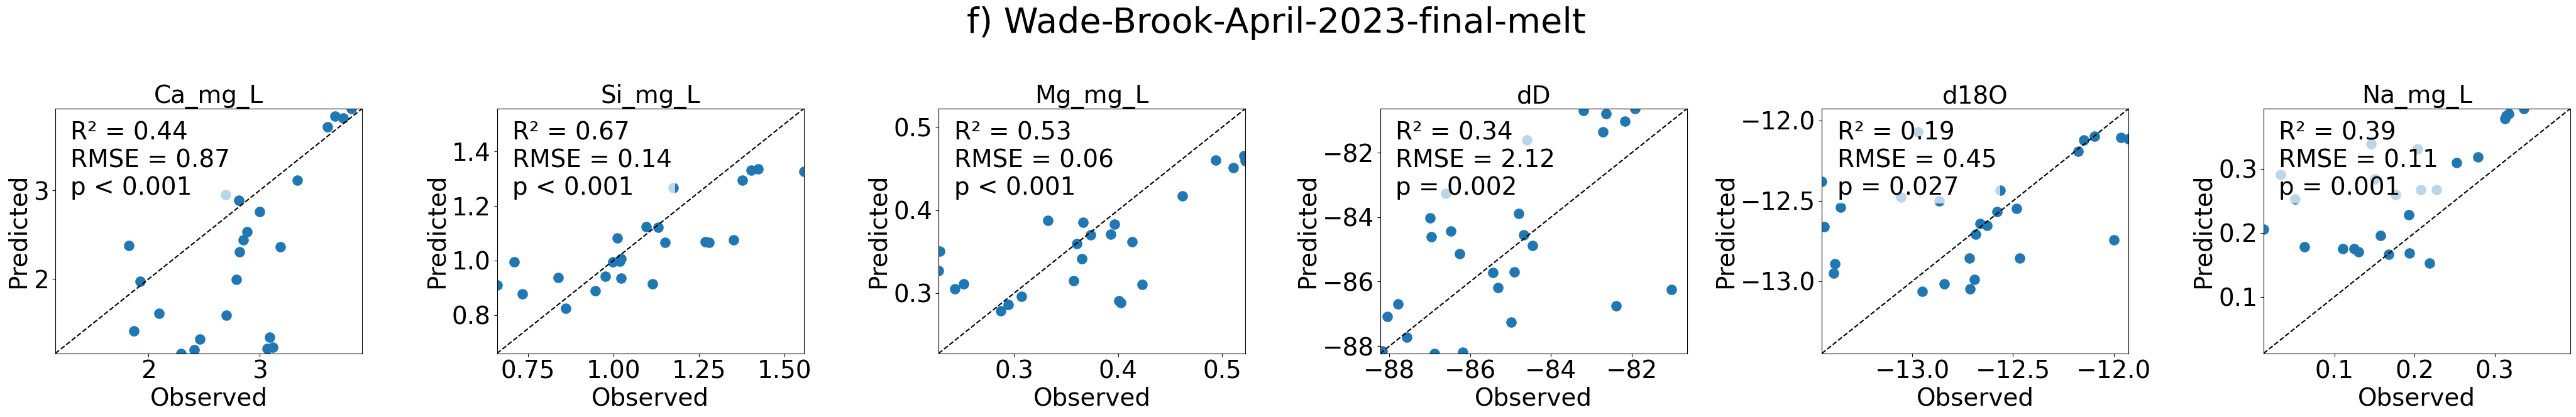

In [21]:
import importlib
import sys
from pathlib import Path
import pandas as pd

# Set up home path and working repo dir 
HOME = Path.home()
repo_dir = HOME / "OneDrive/git-repos/LCBP-interannual-EMMAs"

if str(repo_dir) not in sys.path:
    sys.path.append(str(repo_dir))

# Import EMMA module
import EMMA.event_emma as em  
import EMMA.event_pca_error as ep
importlib.reload(ep)
importlib.reload(em)

# Define data directory using relative path logic
data_dir = repo_dir / "Data/GrabSample_data"

output_dir = repo_dir / "Output/EMMA-uncertainty/Tracer_regressions/" 

# Load the full RI23 dataset
df = pd.read_csv(data_dir / "RI23-IC-ICP-isotope-toc-joined.csv")

####################
# Wade RI23 events #
####################

# Event C
# Wade freshet
# Endmembers: 
    # RI23-5018 Groundwater Bear Pond 03/10/23
    # RI23-5006 Groundwater High Pond 03/01/23 (could be 03/10/23, doesn't really matter)
    # RI23-5010 Precip 04/10
    # RI23-1098 Snowmelt lysimeter 4/11
    # RI23-5011 Soil water lysimeter wet 4/12
    # RI23-5012 Snowmelt lysimeter 4/12
    # RI23-1063 Snowmelt lysimeter 3/28

    # Adding in RI22 and RI25 groundwater samples to try and reduce uncertainty
        # RIRI22-0860 Bear Pond GW
        # RI22-0859 High Pond GW
        # RI25-1111 Baseflow
        # RI25-1126 Baseflow
        # RI25-1183 Baseflow
        # RI25-1201 Baseflow
        # RI25-1290 Basedlow

wade_fmelt_fractions_df, wade_fmelt_scaler, wade_fmelt_pca, wade_fmelt_endmembers_df = em.run_emma_event(
    data=df,
    site="Wade",
    start_date="2023-03-30 00:00:00",
    end_date="2023-04-15 00:00:00",
    endmember_ids=[
                   "RI23-5018", "RI23-5006", # Homeowner well groundwater March 2023
                   #"RI22-0860", "RI22-0859", # Homeowner well groundwater 2022
                   #"RI23-1034", # Pre-event baseflow, labeled as GW in Wade index
                   #"RI25-1111", "RI25-1126", "RI25-1183", "RI25-1201", "RI25-1290", # 2025 baseflow samples 
                   "RI23-5005", # Snowmelt lysimeter 02/15/2023
                   "RI23-1063", # Snowmelt lysimeter 3/28
                   #"RI23-1098", # Snowmelt lysimeter 04/11/2023
                   #"RI23-5009", # Soil water lysimeter sample
                   "RI23-5011", # Soil water lysimeter wet 4/12
                   ])

wade_tracers = ['Ca_mg_L', 'Si_mg_L', 'Mg_mg_L', 'dD', 'd18O', 'Na_mg_L']

# Call the prediction function
wade_fmelt_predicted = em.predict_tracers_from_fractions(
    fractions_df=wade_fmelt_fractions_df,
    endmembers_df=wade_fmelt_endmembers_df,
    tracer_cols=wade_tracers
)

# Plot observed vs predicted tracer values
em.plot_observed_vs_predicted(
    title = "f) Wade-Brook-April-2023-final-melt", 
    predicted_df = wade_fmelt_predicted, 
    stream_df = df, 
    tracer_cols = wade_tracers,
    output_dir=output_dir)